<a href="https://colab.research.google.com/github/lucassouza147770-art/MLCB_LG_2026/blob/main/AULA04_MLCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# GERADOR SINTÉTICO DE DADOS - SAC MÓVEIS RESIDENCIAIS
# ==============================================================================
import pandas as pd
import random

templates = {
    'vendas': {
        's': ['', 'Olá', 'Bom dia', 'Gostaria de saber', 'Por favor'],
        'a': ['quero comprar', 'qual o preco do', 'tem cupom para', 'como faco para adquirir', 'desejo orcamento de'],
        'o': ['sofa retratil 3 lugares', 'conjunto de mesa de jantar', 'guarda roupa casal', 'painel para tv', 'colchao queen size']
    },
    'suporte': {
        's': ['', 'Oi', 'Preciso de ajuda', 'Por gentileza', 'Socorro'],
        'a': ['como montar o', 'onde baixo o manual do', 'estou com duvida no', 'veio faltando parafuso no', 'preciso de assistencia para'],
        'o': ['armario de cozinha', 'rack da sala', 'berco do bebe', 'esquema de montagem', 'manual da estante']
    },
    'trocas_devolucoes': {
        's': ['', 'Olá', 'Por favor', 'Gostaria de solicitar', 'Quero abrir'],
        'a': ['preciso trocar o', 'quero devolver a', 'como solicito o estorno do', 'desejo solicitar a troca da', 'como funciona a devolucao do'],
        'o': ['produto com defeito', 'mesa que veio arranhada', 'cadeira no prazo de 7 dias', 'pedido cancelado', 'item com avaria']
    },
    'reclamacoes': {
        's': ['', 'Urgente', 'Pessimo atendimento', 'Absurdo', 'Quero registrar'],
        'a': ['estou indignado com o', 'quero fazer uma queixa do', 'estou reclamando do', 'produto veio quebrado e o', 'atendimento horrivel do'],
        'o': ['atraso na minha entrega', 'servico de montagem', 'sac que nao responde', 'pos venda da loja', 'estado do meu movel']
    },
    'logistica_entregas': {
        's': ['', 'Olá', 'Bom dia', 'Por gentileza', 'Preciso saber'],
        'a': ['onde esta o meu', 'qual o prazo de entrega do', 'como rastreio a', 'qual a transportadora do', 'quando chega o'],
        'o': ['meu pedido', 'codigo de rastreamento', 'movel comprado', 'status do envio', 'agendamento da entrega']
    }
}

amostras = []
random.seed(42)

for intencao, comp in templates.items():
    for _ in range(20):  # Total: 100 amostras (20 por classe)
        s = random.choice(comp['s'])
        a = random.choice(comp['a'])
        o = random.choice(comp['o'])
        frase = f"{s} {a} {o}".strip().capitalize()
        amostras.append({'texto': frase, 'intencao': intencao})

df_moveis = pd.DataFrame(amostras)
df_moveis.to_csv('dataset_moveis_100.csv', index=False, encoding='utf-8')

print(" Dataset 'dataset_moveis_100.csv' criado com 100 frases distribuidas em 5 intencoes!")


 Dataset 'dataset_moveis_100.csv' criado com 100 frases distribuidas em 5 intencoes!


MÉTRICAS GERAIS DO MODELO (KNN)
Acurácia Geral: 100.00%
F1-Score Geral (Weighted): 100.00%

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                    precision    recall  f1-score   support

logistica_entregas       1.00      1.00      1.00         6
       reclamacoes       1.00      1.00      1.00         6
           suporte       1.00      1.00      1.00         6
 trocas_devolucoes       1.00      1.00      1.00         6
            vendas       1.00      1.00      1.00         6

          accuracy                           1.00        30
         macro avg       1.00      1.00      1.00        30
      weighted avg       1.00      1.00      1.00        30



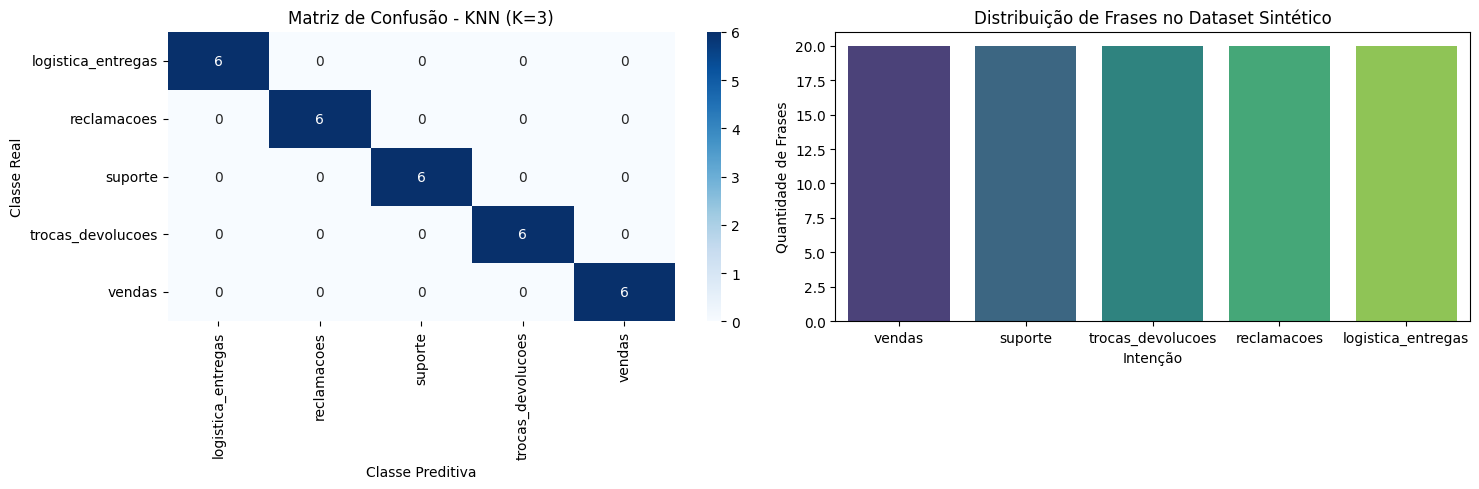

In [4]:
# ==============================================================================
# SCRIPT 2: PIPELINE DE TREINAMENTO, AVALIAÇÃO E GRÁFICOS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 1. Carga dos dados salvos no CSV
df = pd.read_csv('dataset_moveis_100.csv')

# 2. Divisão Estratificada (Treino / Teste)
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'], df['intencao'], test_size=0.30, random_state=42, stratify=df['intencao']
)

# 3. Construção da Pipeline com TF-IDF + KNN (K=3)
pipeline_nlu = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('classifier', KNeighborsClassifier(n_neighbors=3, metric='cosine'))
])

# 4. Treinamento do Modelo
pipeline_nlu.fit(X_train, y_train)

# 5. Avaliação Estatística
y_pred = pipeline_nlu.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print(f"MÉTRICAS GERAIS DO MODELO (KNN)")
print(f"Acurácia Geral: {acc*100:.2f}%")
print(f"F1-Score Geral (Weighted): {f1*100:.2f}%")
print("="*60)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

# 6. Geração dos Gráficos de Avaliação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Matriz de Confusão Heatmap
cm = confusion_matrix(y_test, y_pred)
labels = sorted(df['intencao'].unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matriz de Confusão - KNN (K=3)')
axes[0].set_xlabel('Classe Preditiva')
axes[0].set_ylabel('Classe Real')

# Gráfico 2: Distribuição de Amostras por Classe no Dataset
sns.countplot(data=df, x='intencao', hue='intencao', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribuição de Frases no Dataset Sintético')
axes[1].set_xlabel('Intenção')
axes[1].set_ylabel('Quantidade de Frases')

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# SCRIPT 3: ASSISTENTE VIRTUAL INTERATIVO COM FALLBACK
# ==============================================================================
import numpy as np

LIMIAR_CONFIANCA = 0.50

def processar_mensagem(texto):
    # 1. Obtenção das probabilidades do modelo treinado
    probs = pipeline_nlu.predict_proba([texto])[0]
    maior_prob = np.max(probs)
    intencao = pipeline_nlu.predict([texto])[0]

    # 2. Lógica de decisão por Limiar de Confiança
    if maior_prob >= LIMIAR_CONFIANCA:
        print(f"\nBot [Intenção: {intencao.upper()} | Confiança: {maior_prob*100:.1f}%]: ", end="")

        if intencao == "investimentos":
            print("Temos opções de CDB, LCI/LCA e Tesouro Direto. Qual seu perfil de risco?")
        elif intencao == "consultas":
            print("Seu saldo disponível é de R$ 4.820,50. Deseja consultar seu extrato?")
        elif intencao == "pagamentos":
            print("Área de pagamentos iniciada. Por favor, digite ou cole o código de barras.")
        elif intencao == "financiamentos":
            print("Simulador de crédito aberto. Qual o valor do bem que deseja financiar?")

    else:
        # Fallback ativo encaminhando para atendente humano
        print(f"\nBot: [FALLBACK - Confiança baixa: {maior_prob*100:.1f}%]")
        print("Desculpe, não consegui entender sua solicitação. Por favor, aguarde um momento enquanto encaminho você para um atendente humano...")

# ------------------------------------------------------------------------------
# LOOP DE INTERAÇÃO COM O CLIENTE
# ------------------------------------------------------------------------------
print("="*60)
print("=== CHATBOT BANCÁRIO - ATENDIMENTO AO CLIENTE ===")
print("Digite sua mensagem abaixo. Para encerramento, digite 'sair'.")
print("="*60 + "\n")

while True:
    entrada = input("Você: ").strip()

    if entrada.lower() == 'sair':
        print("Bot: Atendimento finalizado. Obrigado por utilizar nossos serviços!")
        break

    if not entrada:
        continue

    processar_mensagem(entrada)
    print("-" * 60)

=== CHATBOT BANCÁRIO - ATENDIMENTO AO CLIENTE ===
Digite sua mensagem abaixo. Para encerramento, digite 'sair'.

Você: Olá quero comprar sofa retratil 3 lugares,vendas

Bot [Intenção: VENDAS | Confiança: 100.0%]: ------------------------------------------------------------


KeyboardInterrupt: Interrupted by user

In [14]:
# ==============================================================================
# ATIVIDADE 1: CHATBOT VERSÃO 1 (KNN)
# ==============================================================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


# 1. Carregar dataset do CSV
df = pd.read_csv('dataset_moveis_100.csv')


# 2. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'],
    df['intencao'],
    test_size=0.30,
    random_state=42,
    stratify=df['intencao']
)


# TODO 1: Pipeline TF-IDF + KNN
pipeline_knn = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
    ('classifier', KNeighborsClassifier(
        n_neighbors=3,
        metric='cosine'
    ))
])


# TODO 2: Treinar o modelo
pipeline_knn.fit(X_train, y_train)


# TODO 3: Fazer previsões
y_pred = pipeline_knn.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# Limiar de confiança
LIMIAR_CONFIANCA = 0.50


print("\n=== INICIANDO BATERIA DE TESTES (10 INPUTS OBRIGATÓRIOS) ===")


# 10 testes
for i in range(1, 11):

    print(f"\n[Teste {i}/10]")

    # TODO 4
    frase = input("Digite a frase do cliente: ").strip()

    # TODO 5
    probs = pipeline_knn.predict_proba([frase])
    maior_prob = np.max(probs)
    intencao = pipeline_knn.predict([frase])[0]

    # TODO 6
    if maior_prob >= LIMIAR_CONFIANCA:
        print(f"Bot [Intenção: {intencao.upper()} | Confiança: {maior_prob:.1%}]")

    else:
        print(f"Bot: [FALLBACK - Confiança baixa: {maior_prob:.2%}]")
        print("Desculpe, não entendi sua solicitação. Encaminhando você para um atendente humano...")

pass

                    precision    recall  f1-score   support

logistica_entregas       1.00      1.00      1.00         6
       reclamacoes       1.00      1.00      1.00         6
           suporte       1.00      1.00      1.00         6
 trocas_devolucoes       1.00      1.00      1.00         6
            vendas       1.00      1.00      1.00         6

          accuracy                           1.00        30
         macro avg       1.00      1.00      1.00        30
      weighted avg       1.00      1.00      1.00        30

[[6 0 0 0 0]
 [0 6 0 0 0]
 [0 0 6 0 0]
 [0 0 0 6 0]
 [0 0 0 0 6]]

=== INICIANDO BATERIA DE TESTES (10 INPUTS OBRIGATÓRIOS) ===

[Teste 1/10]
Digite a frase do cliente: Meu pedido ainda não chegou
Bot [Intenção: LOGISTICA_ENTREGAS | Confiança: 100.0%]

[Teste 2/10]
Digite a frase do cliente: Quero devolver minha mesa
Bot [Intenção: TROCAS_DEVOLUCOES | Confiança: 66.7%]

[Teste 3/10]
Digite a frase do cliente: Veio um parafuso faltando
Bot [Intenção: REC

In [15]:
# ==============================================================================
# ATIVIDADE 2: CHATBOT VERSÃO 2 (DECISION TREE)
# ==============================================================================

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


df = pd.read_csv('dataset_moveis_100.csv')

X_train, X_test, y_train, y_test = train_test_split(
    df['texto'],
    df['intencao'],
    test_size=0.30,
    random_state=42,
    stratify=df['intencao']
)

pipeline_tree = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])



pipeline_tree.fit(X_train, y_train)



y_pred = pipeline_tree.predict(X_test)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))



LIMIAR_CONFIANCA = 0.50


print("\n=== INICIANDO BATERIA DE TESTES (8 INPUTS OBRIGATÓRIOS) ===")


for i in range(1, 9):

    print(f"\n[Teste {i}/8]")

    # Solicita a frase do usuário
    frase = input("Digite a frase do cliente: ").strip()

    # Probabilidades das classes
    probs = pipeline_tree.predict_proba([frase])

    # Maior probabilidade encontrada
    maior_prob = np.max(probs)

    # Intenção prevista
    intencao = pipeline_tree.predict([frase])[0]


    # Regra de decisão usando o limiar de 50%
    if maior_prob >= LIMIAR_CONFIANCA:

        print(
            f"Bot [Intenção: {intencao.upper()} | "
            f"Confiança: {maior_prob:.1%}]"
        )

    else:

        print(
            f"Bot: [FALLBACK - Confiança baixa: "
            f"{maior_prob:.2%}]"
        )

        print(
            "Desculpe, não entendi sua solicitação. "
            "Encaminhando você para um atendente humano..."
        )


=== RELATÓRIO DE CLASSIFICAÇÃO ===
                    precision    recall  f1-score   support

logistica_entregas       0.80      0.67      0.73         6
       reclamacoes       1.00      0.67      0.80         6
           suporte       0.75      1.00      0.86         6
 trocas_devolucoes       0.83      0.83      0.83         6
            vendas       0.71      0.83      0.77         6

          accuracy                           0.80        30
         macro avg       0.82      0.80      0.80        30
      weighted avg       0.82      0.80      0.80        30


=== MATRIZ DE CONFUSÃO ===
[[4 0 0 0 2]
 [1 4 1 0 0]
 [0 0 6 0 0]
 [0 0 1 5 0]
 [0 0 0 1 5]]

=== INICIANDO BATERIA DE TESTES (8 INPUTS OBRIGATÓRIOS) ===

[Teste 1/8]
Digite a frase do cliente: Quero saber o preço de uma mesa
Bot [Intenção: VENDAS | Confiança: 100.0%]

[Teste 2/8]
Digite a frase do cliente: Meu sofá ainda não foi entregue
Bot [Intenção: LOGISTICA_ENTREGAS | Confiança: 100.0%]

[Teste 3/8]
Digite a fr